# CodeAlpha Internship – Project 2
## UK Data Analyst Job Market – Exploratory Data Analysis (EDA)

### Introduction

This project explores the UK Data Analyst job dataset collected during Project 1. The aim is to understand the data, identify trends and patterns, and detect potential data quality issues.

### Questions

- Which job titles are most common?
- Which locations have the most job opportunities?
- How many jobs include salary information?
- What is the typical advertised salary?
- Which technical skills are most requested?
- Are there any unusual values or data quality issues?

## 1. Data Understanding and Preparation

The dataset collected during Project 1 is loaded and inspected to understand its structure, data types and data quality.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("/Users/shabbarhasnainkhan/UK_Data_Analyst_Jobs_Raw.csv")

In [3]:
df.shape

(377, 6)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 377 entries, 0 to 376
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Job Title  377 non-null    object
 1   Company    377 non-null    object
 2   Location   377 non-null    object
 3   Salary     299 non-null    object
 4   Skills     377 non-null    object
 5   Job URL    377 non-null    object
dtypes: object(6)
memory usage: 17.8+ KB


In [5]:
df.isnull().sum()

Job Title     0
Company       0
Location      0
Salary       78
Skills        0
Job URL       0
dtype: int64

In [7]:
#Duplicate Records
df.duplicated().sum()

np.int64(0)

In [8]:
df["Job Title"].head(20)

0                      Data Analyst Daventry
1                   Data Analyst Chislehurst
2      KYC & Data Remediation Analyst London
3              Data Analyst Trainee Hounslow
4               AI Enablement Analyst London
5                        Data Analyst London
6              Trainee Data Analyst Hastings
7              Data Analyst Trainee Rochdale
8                Trainee Data Analyst Ilford
9                 Data Analyst Trainee Crewe
10        Data / Business Analyst Manchester
11           Trainee Data Analyst Twickenham
12             Data Analyst Trainee Nuneaton
13                 Data Analyst Trainee York
14           CAD Data Quality Analyst Gaydon
15          Data Analyst Trainee Bournemouth
16    Supply Chain Data Analyst Peterborough
17           Data Analyst Trainee Twickenham
18           Data Analyst Trainee The Collon
19                  Data Analyst West Sussex
Name: Job Title, dtype: object

In [9]:
df["Location"].value_counts().head(15)

Location
London                 102
West Sussex             14
Manchester              12
United Kingdom          11
Glasgow                  5
Brighton                 5
Bristol                  5
Leicester                4
Bradford                 4
Newcastle Upon Tyne      4
Watford                  3
Enfield                  3
Gateshead                3
Milton Keynes            3
Solihull                 3
Name: count, dtype: int64

In [10]:
df[["Job Title", "Location"]].head(20)

,Job Title,Location
0,Data Analyst Daventry,Daventry
1,Data Analyst Chislehurst,Chislehurst
2,KYC & Data Remediation Analyst London,London
3,Data Analyst Trainee Hounslow,Hounslow
4,AI Enablement Analyst London,London
5,Data Analyst London,London
6,Trainee Data Analyst Hastings,Hastings
7,Data Analyst Trainee Rochdale,Rochdale
8,Trainee Data Analyst Ilford,Ilford
9,Data Analyst Trainee Crewe,Crewe


In [11]:
#Clean Job Titles
df["Job Title"] = df.apply(
    lambda row: row["Job Title"].replace(row["Location"], "").strip(), axis=1
)

In [12]:
df[["Job Title", "Location"]].head(10)

,Job Title,Location
0,Data Analyst,Daventry
1,Data Analyst,Chislehurst
2,KYC & Data Remediation Analyst,London
3,Data Analyst Trainee,Hounslow
4,AI Enablement Analyst,London
5,Data Analyst,London
6,Trainee Data Analyst,Hastings
7,Data Analyst Trainee,Rochdale
8,Trainee Data Analyst,Ilford
9,Data Analyst Trainee,Crewe


The job titles were cleaned by removing location names that were appended to the end of the title. The original location information is retained in the separate `Location` column.

In [13]:
df["Salary"].head(10)

0    £45,000 - £47,000
1                  NaN
2                  NaN
3    £30,000 - £50,000
4    £50,000 - £55,000
5                  NaN
6    £30,000 - £50,000
7    £30,000 - £50,000
8    £30,000 - £50,000
9    £30,000 - £50,000
Name: Salary, dtype: object

In [14]:
df["Salary"].notna().sum()

np.int64(299)

In [15]:
#Create Salary Midpoint
def salary_midpoint(salary):
    if pd.isna(salary):
        return None
    
    salary = salary.replace("£", "").replace(",", "")
    values = salary.split("-")
    
    if len(values) == 2:
        minimum = float(values[0].strip())
        maximum = float(values[1].strip())
        return (minimum + maximum) / 2
    
    return None

df["Salary_Midpoint"] = df["Salary"].apply(salary_midpoint)

In [16]:
df[["Salary", "Salary_Midpoint"]].head(10)

,Salary,Salary_Midpoint
0,"£45,000 - £47,000",46000.0
1,NaN,NaN
2,NaN,NaN
3,"£30,000 - £50,000",40000.0
4,"£50,000 - £55,000",52500.0
5,NaN,NaN
6,"£30,000 - £50,000",40000.0
7,"£30,000 - £50,000",40000.0
8,"£30,000 - £50,000",40000.0
9,"£30,000 - £50,000",40000.0


In [17]:
df["Salary_Midpoint"].describe()

count      299.000000
mean     40879.005301
std      14464.457533
min         11.920000
25%      40000.000000
50%      40000.000000
75%      40000.000000
max      95000.000000
Name: Salary_Midpoint, dtype: float64

In [18]:
#Identify the Salary Anomaly
df[df["Salary_Midpoint"] < 20000 ][["Job Title", "Salary", "Salary_Midpoint"]]

,Job Title,Salary,Salary_Midpoint
10,Data / Business Analyst,£400 - £500,450.000
37,Salesforce Data Analyst,£220 - £240,230.000
81,IT PMO - SC Cleared,£50 - £55.33,52.665
163,Data Analyst - Snowflake / Salesforce,£400 - £475,437.500
215,Data Migration Analyst,£275 - £300,287.500
246,Senior Data Analyst - Insurance (AI & Data),£400 - £500,450.000
248,Data Quality Analyst,£550 - £600,575.000
264,AI Data Governance Analyst Contract,£400 - £450,425.000
268,Data Visualisation Analyst,£500 - £550,525.000
272,Data Governance Analyst,£350 - £450,400.000


Some salary values appear unusually low compared with typical annual salaries. Further inspection suggests that the dataset contains different salary formats, such as annual salaries and contract/hourly rates. These values should therefore be treated carefully during salary analysis.

In [19]:
df[df["Salary_Midpoint"] < 20000 ][["Job Title", "Salary", "Job URL"]]

,Job Title,Salary,Job URL
10,Data / Business Analyst,£400 - £500,https://www.reed.co.uk/jobs/data-business-anal...
37,Salesforce Data Analyst,£220 - £240,https://www.reed.co.uk/jobs/salesforce-data-an...
81,IT PMO - SC Cleared,£50 - £55.33,https://www.reed.co.uk/jobs/it-pmo-sc-cleared/...
163,Data Analyst - Snowflake / Salesforce,£400 - £475,https://www.reed.co.uk/jobs/data-analyst-snowf...
215,Data Migration Analyst,£275 - £300,https://www.reed.co.uk/jobs/data-migration-ana...
246,Senior Data Analyst - Insurance (AI & Data),£400 - £500,https://www.reed.co.uk/jobs/senior-data-analys...
248,Data Quality Analyst,£550 - £600,https://www.reed.co.uk/jobs/data-quality-analy...
264,AI Data Governance Analyst Contract,£400 - £450,https://www.reed.co.uk/jobs/ai-data-governance...
268,Data Visualisation Analyst,£500 - £550,https://www.reed.co.uk/jobs/data-visualisation...
272,Data Governance Analyst,£350 - £450,https://www.reed.co.uk/jobs/data-governance-an...


In [20]:
#Create a New Annual Salary Col
df["Annual Salary"] = df["Salary_Midpoint"].where(
    df["Salary_Midpoint"] >= 20000
)

In [21]:
df["Annual Salary"].describe()

count      282.000000
mean     43320.067376
std      10802.698773
min      21500.000000
25%      40000.000000
50%      40000.000000
75%      40000.000000
max      95000.000000
Name: Annual Salary, dtype: float64

In [22]:
#Check missing salary after cleaning
df["Annual Salary"].isna().sum()

np.int64(95)

In [23]:
df["Annual Salary"].notna().sum()

np.int64(282)

Salary data contained both annual salary ranges and lower contract/hourly rates. For salary analysis, values below £20,000 were excluded from the annual salary calculations rather than being treated as annual salaries.

## 2. Exploratory Data Analysis

In [24]:
df["Job Title"].value_counts().head(10)

Job Title
Data Analyst Trainee                                          133
Data Analyst                                                   67
Trainee Data Analyst                                           66
Senior Data Analyst                                            11
Graduate Data Analyst                                           4
Data Business Analyst                                           3
Trainee AI Data Analyst (No Experience Needed – UK Remote)      3
Data Governance Analyst                                         3
Junior Data Analyst                                             3
AI Business Analyst                                             2
Name: count, dtype: int64

The dataset contains a high number of trainee-level positions. Similar titles such as "Data Analyst Trainee" and "Trainee Data Analyst" appear separately and may represent similar roles.

In [25]:
#Analyse Job Title Categories
terms = ["Trainee", "Senior", "Junior", "Graduate", "Apprentice"]

for term in terms:
    count = df["Job Title"].str.contains(term, case=False, na=False).sum()
    print(f"{term}: {count}")

Trainee: 208
Senior: 20
Junior: 6
Graduate: 4
Apprentice: 1


In [26]:
#Location Analysis
df["Location"].value_counts().head(10)

Location
London                 102
West Sussex             14
Manchester              12
United Kingdom          11
Glasgow                  5
Brighton                 5
Bristol                  5
Leicester                4
Bradford                 4
Newcastle Upon Tyne      4
Name: count, dtype: int64

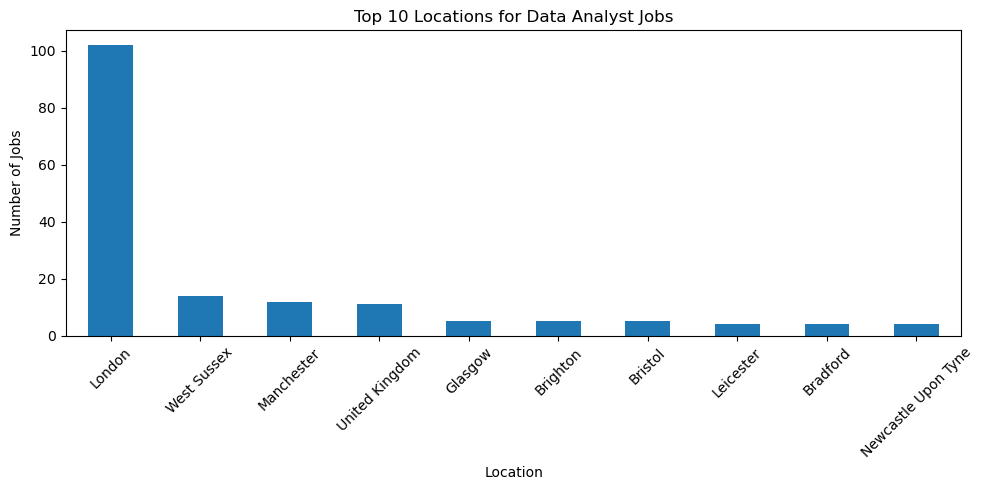

In [27]:
#Location Visualisation
location_counts = df["Location"].value_counts().head(10)

location_counts.plot(kind="bar", figsize=(10, 5))

plt.title("Top 10 Locations for Data Analyst Jobs")
plt.xlabel("Location")
plt.ylabel("Number of Jobs")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

London has the highest number of job postings in the dataset, followed by West Sussex and Manchester.

In [28]:
#Salary Analysis
df["Annual Salary"].describe()

count      282.000000
mean     43320.067376
std      10802.698773
min      21500.000000
25%      40000.000000
50%      40000.000000
75%      40000.000000
max      95000.000000
Name: Annual Salary, dtype: float64

In [29]:
print("Mean Salary: £{:,.0f}".format(df["Annual Salary"].mean()))
print("Median Salary: £{:,.0f}".format(df["Annual Salary"].median()))

Mean Salary: £43,320
Median Salary: £40,000


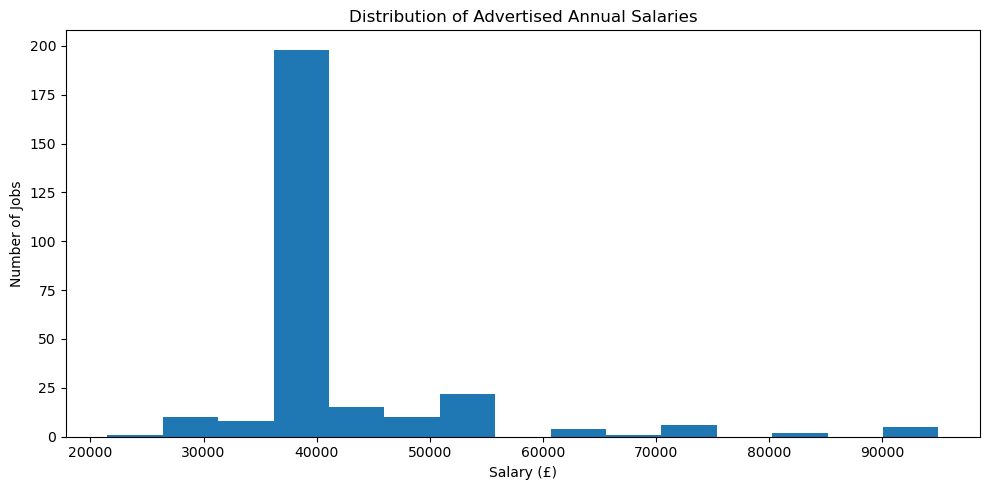

In [30]:
df["Annual Salary"].dropna().plot(
    kind="hist",
    bins=15,
    figsize=(10, 5)
)

plt.title("Distribution of Advertised Annual Salaries")
plt.xlabel("Salary (£)")
plt.ylabel("Number of Jobs")
plt.tight_layout()
plt.show()

The salary distribution shows that most advertised annual salaries are concentrated around £40,000, while a smaller number of roles offer substantially higher salaries.

In [31]:
#Skills Analysis
skill_counts = {}

for skills in df["Skills"]:
    for skill in skills.split(", "):
        if skill:
            skill_counts[skill] = skill_counts.get(skill, 0) + 1

skill_counts = pd.Series(skill_counts).sort_values(ascending=False)

skill_counts.head(10)

R                   377
Excel               348
SQL                 330
Power BI            309
Python              296
Tableau             281
Azure                43
Machine Learning     41
AWS                  13
Statistics            5
dtype: int64

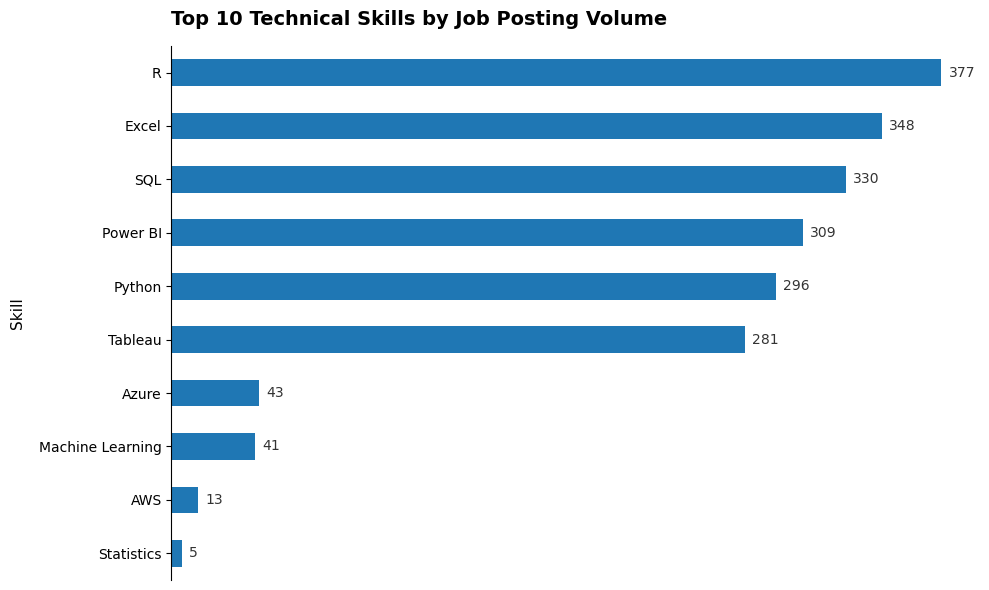

In [49]:
skill_counts.head(10).sort_values(ascending=True).plot(
    kind="barh",
    figsize=(10, 6),
    xticks=[]
)

plt.title("Top 10 Technical Skills by Job Posting Volume", fontsize=14, fontweight="bold", pad=15, loc="left",)
plt.bar_label(bars, padding=5, fontsize=10, color="#333333")
#plt.xlabel("Number of Job Postings", fontsize=11, labelpad=10)
plt.ylabel("Skill", fontsize=11, labelpad=10)
plt.gca().spines[["top", "right", "bottom"]].set_visible(False)
plt.tight_layout()
plt.show()

In [47]:
df[df["Annual Salary"] > 70000][
    ["Job Title", "Location", "Annual Salary"]
].sort_values("Annual Salary", ascending=False)

,Job Title,Location,Annual Salary
184,Data Analyst,Brighton,95000.0
208,Data Analyst,Manchester,95000.0
259,Data Analyst,Glasgow,95000.0
282,Data Analyst,London,95000.0
337,Data Analyst,Glasgow,95000.0
115,Exposure / Quantitative Data Analyst,City of London,85000.0
225,Data Analyst - Commercial Insight,London,85000.0
48,Senior Data Analyst - - Tableau - Snowflake -...,London,75000.0
63,Senior Data Analyst,London,75000.0
176,Senior Data Analyst,London,75000.0


A small number of higher salary values were identified, including salaries of £95,000. These were associated with Data Analyst roles and were retained as valid observations for the analysis.

In [48]:
print("Unique skills:", len(skill_counts))
print("Jobs with no skills listed:", (df["Skills"] == "").sum())

Unique skills: 11
Jobs with no skills listed: 0


## 3. Key Findings & Conclusion

### Key Findings

- Trainee roles were the most common in the dataset, with 208 job postings containing the word "Trainee".
- London had the highest number of job postings, with 102 listings.
- 299 out of 377 job postings included salary information.
- The average annual salary was approximately £43,320, while the median was £40,000.
- R, Excel, SQL, Power BI, Python, and other technical skills were frequently requested across the job postings.
- Some salary values represented different pay formats, so lower values were excluded from the annual salary analysis.
- A small number of higher salaries were identified, but they were retained as valid observations.

### Conclusion

The analysis provided an overview of the UK Data Analyst job market based on 377 job postings collected from Reed.co.uk. The EDA identified patterns in job titles, locations, salaries and technical skills, while also highlighting important data quality issues.

The dataset is now prepared for further analysis and visualisation.

In [50]:
df.to_csv("UK_Data_Analyst_Jobs_Cleaned.csv", index=False)